# Regresión Lineal Múltiple — Predicción de potencia en granjas de convertidores de energía undimotriz (WEC)

**Cuadernillo modificado a partir de `02_reg_lin_mul_01.ipynb`**.

En este cuadernillo se reemplaza el dataset original (`ex1data2.txt`, 47 ejemplos, 2 características) por un dataset real de mayor escala:

**Large-scale Wave Energy Farm — Perth 49 (WEC_Perth_49.csv)**

- Repositorio de origen: UCI Machine Learning Repository — *"Large-scale Wave Energy Farm"* dataset (Neshat et al.).
- El dataset describe una granja de **49 convertidores de energía undimotriz (WEC / boyas)** ubicados frente a la costa de Perth (Australia). Cada fila es una configuración distinta del arreglo de boyas.
- **Columnas `X_i`, `Y_i` (i = 1..49):** coordenadas (x, y) en metros de la boya *i* dentro del arreglo → **98 variables de entrada (n = 98 ≥ 20)**.
- **Columnas `Power_i` (i = 1..49):** potencia individual generada por la boya *i*.
- **`qW`:** factor de calidad de interacción (q-factor) del arreglo.
- **`Total_Power`:** potencia total generada por el arreglo completo (suma de interacción de las 49 boyas) → **variable objetivo (y)**.

El objetivo es entrenar un modelo de **regresión lineal múltiple** (descenso por el gradiente + ecuación de la normal) que, a partir de la **disposición geométrica de las boyas (X_i, Y_i)**, sea capaz de **inferir la potencia total (`Total_Power`)** que generará el arreglo — un problema real de optimización de layout en energías renovables.

Se mantiene la misma estructura pedagógica del cuadernillo original: normalización de características, función de costo vectorizada, descenso por el gradiente, selección de $\alpha$, ecuación de la normal e inferencia; pero el flujo de carga y preprocesamiento de datos se reescribe **usando Pandas**, tal como lo requiere la actividad.


In [ ]:

import os

# Computación vectorial y científica para python
import numpy as np
# Pandas: apertura y preprocesamiento del dataset
import pandas as pd

# Librerías para graficación (trazado de gráficos)
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

# Semilla para reproducibilidad
np.random.seed(42)


## 1. Carga y exploración del dataset (con Pandas)

Se descarga/adjunta el archivo `WEC_Perth_49.csv` en la carpeta `data/` del repositorio y se carga con `pandas.read_csv`.


In [2]:
# Ruta del dataset dentro del repositorio
DATA_PATH = os.path.join('..', 'data', 'WEC_Perth_49.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'WEC_Perth_49.csv'  # fallback si se ejecuta desde la misma carpeta

df = pd.read_csv(DATA_PATH)

print('Forma del dataset (filas, columnas):', df.shape)
df.head()


Forma del dataset (filas, columnas): (36043, 149)


,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88919.83,98746.68,101346.15,98875.57,101618.32,100941.00,99611.35,96719.14,0.87,4103680.44
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,88855.14,98760.96,101338.59,98971.58,101632.28,100943.59,99589.25,96735.04,0.87,4105661.06
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,88005.30,98630.24,100432.73,98803.01,101064.48,100948.38,99028.87,96286.71,0.79,3752648.77


In [3]:
# Información general del dataset: tipos de datos y nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 36043 entries, 0 to 36042
Columns: 149 entries, X1 to Total_Power
dtypes: float64(149)
memory usage: 41.0 MB


In [4]:
# Estadística descriptiva general
df.describe().T


,count,mean,std,min,25%,50%,75%,max
X1,36043.0,3.665971e+02,307.911246,0.00,65.77,250.00,600.000,1000.00
Y1,36043.0,1.870955e+01,44.043295,0.00,0.00,0.00,0.000,885.59
X2,36043.0,4.263140e+02,265.781316,0.00,200.00,346.09,745.980,1000.00
Y2,36043.0,5.108576e+01,90.151852,0.00,0.00,37.52,37.900,939.26
X3,36043.0,4.772956e+02,270.322011,0.00,289.95,400.00,689.800,1000.00
...,...,...,...,...,...,...,...,...
Power47,36043.0,9.810628e+04,4263.508074,63028.26,97154.63,99805.92,100955.350,102892.11
Power48,36043.0,9.746266e+04,3134.420742,61717.31,96869.74,98710.73,99064.495,102275.48
Power49,36043.0,9.613492e+04,3889.098339,47257.43,96319.55,96543.09,97036.300,101876.14
qW,36043.0,8.338493e-01,0.026052,0.72,0.81,0.83,0.860,0.88


In [5]:
# Verificación de valores nulos / faltantes
print('Total de valores nulos en el dataset:', df.isnull().sum().sum())


Total de valores nulos en el dataset: 0


### Cumplimiento de los requisitos de tamaño del dataset

- **m (número de instancias)** debe ser **≥ 20 000**.
- **n (número de características de entrada)** debe ser **≥ 20**.


In [6]:
m_total, cols_total = df.shape
print(f'Numero de ejemplos (filas)      m = {m_total}')
print(f'Numero de columnas totales        = {cols_total}')
assert m_total >= 20000, 'El dataset no cumple m >= 20000'
print('m >= 20000 ->', m_total >= 20000)


Numero de ejemplos (filas)      m = 36043
Numero de columnas totales        = 149
m >= 20000 -> True


## 2. Preprocesamiento con Pandas: selección de variables

Se seleccionan como **características de entrada (X)** las coordenadas de posición de las 49 boyas (`X1..X49`, `Y1..Y49`), y como **variable objetivo (y)** la potencia total generada `Total_Power`.

Se descartan las columnas `Power_i` y `qW` como entrada, ya que son variables derivadas de la simulación de potencia (fugarían información directa del objetivo); el problema real y útil de negocio es predecir la potencia total a partir únicamente de la disposición geométrica del arreglo, para poder optimizar el layout antes de simular.


In [7]:
# Selección de columnas de posición (features) usando Pandas
feature_cols = [c for c in df.columns if (c.startswith('X') or c.startswith('Y')) and c[1:].isdigit()]
feature_cols = sorted(feature_cols, key=lambda c: (int(c[1:]), c[0]))

target_col = 'Total_Power'

print(f'Numero de caracteristicas de entrada n = {len(feature_cols)}')
assert len(feature_cols) >= 20, 'El dataset no cumple n >= 20'
print('n >= 20 ->', len(feature_cols) >= 20)

X_df = df[feature_cols].copy()
y_df = df[target_col].copy()

X_df.head()


Numero de caracteristicas de entrada n = 98
n >= 20 -> True


,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,X45,Y45,X46,Y46,X47,Y47,X48,Y48,X49,Y49
0,600.0,0.0,546.16,37.50,489.79,74.88,432.47,112.05,650.0,0.0,...,400.0,800.0,346.16,837.50,289.79,874.88,232.47,912.05,0.0,1010.0
1,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,400.0,800.0,346.16,837.50,289.79,874.88,232.47,912.05,0.0,1010.0
2,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,400.0,800.0,346.16,837.50,289.79,874.88,232.47,912.05,0.0,1010.0
3,593.0,12.0,546.16,37.50,489.79,74.88,432.47,112.05,644.0,8.0,...,400.0,800.0,346.16,837.50,289.79,874.88,232.47,912.05,0.0,1010.0
4,200.0,0.0,146.17,37.53,89.76,74.93,32.40,112.18,400.0,0.0,...,800.0,800.0,746.17,837.53,689.76,874.93,632.40,912.18,0.0,1010.0


In [8]:
# Conversion a arreglos numpy para el algebra lineal del modelo
X = X_df.values.astype(float)
y = y_df.values.astype(float)

m, n = X.shape
print(f'm (ejemplos) = {m},  n (caracteristicas) = {n}')


m (ejemplos) = 36043,  n (caracteristicas) = 98


## 3. División en conjunto de entrenamiento y prueba

Se separa el dataset en **80% entrenamiento / 20% prueba**, mezclando aleatoriamente los índices (semilla fija para reproducibilidad). El conjunto de prueba se usa únicamente para evaluar el error final del modelo (nunca se usa para ajustar $\theta$ ni para calcular la normalización).


In [9]:
indices = np.random.permutation(m)
test_size = int(0.2 * m)

test_idx = indices[:test_size]
train_idx = indices[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

m_train, m_test = X_train.shape[0], X_test.shape[0]
print(f'Ejemplos de entrenamiento: {m_train}')
print(f'Ejemplos de prueba       : {m_test}')


Ejemplos de entrenamiento: 28835
Ejemplos de prueba       : 7208


## 4. Normalización de características

Al igual que en el cuadernillo original, se normalizan las características (media 0, desviación estándar 1) para que el descenso por el gradiente converja más rápido. Los parámetros de normalización ($\mu$, $\sigma$) se calculan solo con el conjunto de entrenamiento y se aplican también al conjunto de prueba.

Adicionalmente, dado que `Total_Power` tiene una magnitud grande (≈ 4×10⁶), también se normaliza la variable objetivo `y`; esto evita desbordamientos numéricos (`overflow`) durante el descenso por el gradiente y permite usar una tasa de aprendizaje razonable. Al finalizar el entrenamiento, las predicciones se revierten a la escala original de vatios.


In [10]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [11]:
# Normalizacion de las caracteristicas (mu, sigma calculados SOLO en train)
X_train_norm, mu_X, sigma_X = featureNormalize(X_train)
X_test_norm = (X_test - mu_X) / sigma_X

# Normalizacion de la variable objetivo (mu, sigma calculados SOLO en train)
mu_y = np.mean(y_train)
sigma_y = np.std(y_train)

y_train_norm = (y_train - mu_y) / sigma_y
y_test_norm = (y_test - mu_y) / sigma_y

print('Media/desv. de las 5 primeras caracteristicas:')
print('mu   :', mu_X[:5])
print('sigma:', sigma_X[:5])
print(f'mu_y = {mu_y:.2f}   sigma_y = {sigma_y:.2f}')


Media/desv. de las 5 primeras caracteristicas:
mu   : [367.07953078  18.7520978  427.563648    50.66016681 476.99903243]
sigma: [308.1862667   44.20419069 266.43237417  89.30991118 270.37087656]
mu_y = 3938388.68   sigma_y = 122915.63


In [12]:
# Se añade la columna de unos (termino de intersección theta_0)
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('Forma de X_train_b:', X_train_b.shape)
print('Forma de X_test_b :', X_test_b.shape)


Forma de X_train_b: (28835, 99)
Forma de X_test_b : (7208, 99)


## 5. Función de costo y descenso por el gradiente (multivariable)

Se reutilizan (sin cambios en su formulación matemática) las funciones `computeCostMulti` y `gradientDescentMulti` del cuadernillo original, totalmente vectorizadas con `numpy` para soportar cualquier número de características:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$


In [13]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J


In [14]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


## 6. Selección del coeficiente de aprendizaje $\alpha$

Se prueban varios valores de $\alpha$ durante pocas iteraciones y se grafica $J(\theta)$ vs. número de iteración para cada uno, con el fin de elegir el mayor $\alpha$ que **converge de forma estable** (sin diverger) y logra la caída de costo más rápida.


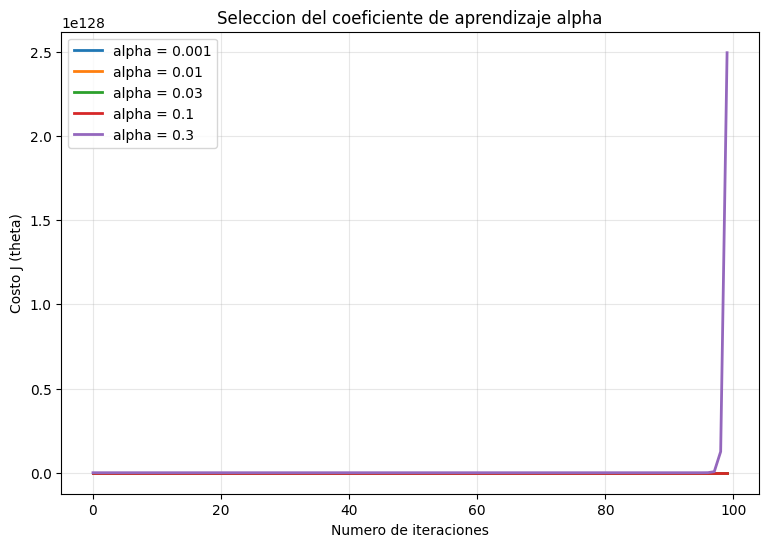

In [15]:
alphas_to_test = [0.001, 0.01, 0.03, 0.1, 0.3]
iters_test = 100

plt.figure(figsize=(9, 6))
for alpha in alphas_to_test:
    theta0 = np.zeros(X_train_b.shape[1])
    _, J_hist = gradientDescentMulti(X_train_b, y_train_norm, theta0, alpha, iters_test)
    plt.plot(np.arange(iters_test), J_hist, lw=2, label=f'alpha = {alpha}')

plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title('Seleccion del coeficiente de aprendizaje alpha')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Con $\alpha = 0.3$ el algoritmo **diverge** (el costo crece sin control), mientras que valores pequeños ($\alpha = 0.001$) convergen muy lentamente. **$\alpha = 0.1$** logra la convergencia más rápida sin diverger, por lo que se selecciona para el entrenamiento final.

## 7. Entrenamiento final del modelo (descenso por el gradiente)

Se entrena el modelo con $\alpha = 0.1$ durante un mayor número de iteraciones, hasta que el costo se estabiliza (convergencia), y se grafica la curva de convergencia de $J(\theta)$ respecto al número de iteración, tal como lo exige la actividad.


In [16]:
alpha = 0.1
num_iters = 1500

theta_init = np.zeros(X_train_b.shape[1])
theta, J_history = gradientDescentMulti(X_train_b, y_train_norm, theta_init, alpha, num_iters)

print(f'Costo inicial J(theta=0)        = {J_history[0]:.6f}')
print(f'Costo final tras {num_iters} iter.  = {J_history[-1]:.6f}')


Costo inicial J(theta=0)        = 0.316683
Costo final tras 1500 iter.  = 0.083647


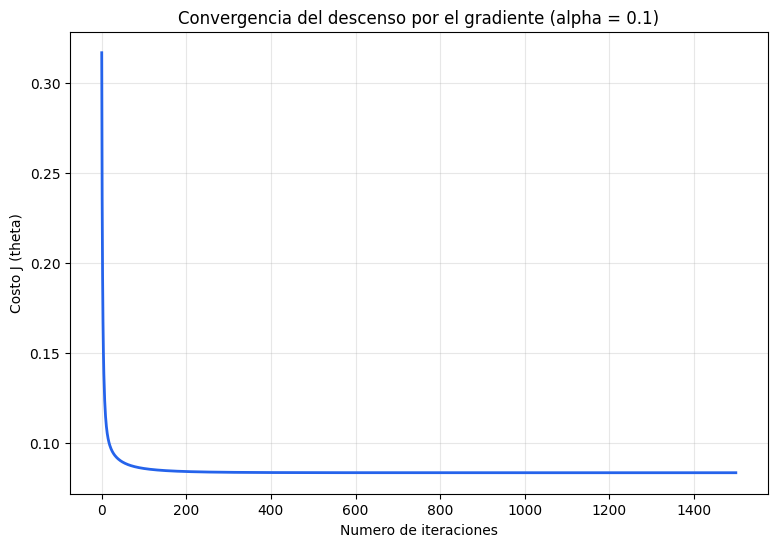

In [17]:
plt.figure(figsize=(9, 6))
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='#2563eb')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title(f'Convergencia del descenso por el gradiente (alpha = {alpha})')
plt.grid(alpha=0.3)
plt.show()


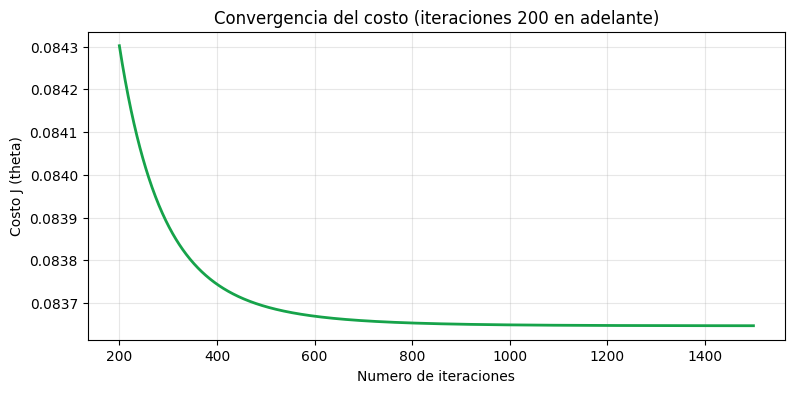

In [18]:
# Zoom sobre las ultimas iteraciones para confirmar estabilizacion del costo
plt.figure(figsize=(9, 4))
plt.plot(np.arange(200, len(J_history)), J_history[200:], lw=2, color='#16a34a')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (theta)')
plt.title('Convergencia del costo (iteraciones 200 en adelante)')
plt.grid(alpha=0.3)
plt.show()


## 8. Evaluación del modelo sobre el conjunto de prueba

Se calculan las predicciones sobre el conjunto de prueba (nunca visto durante el entrenamiento), se revierte la normalización para expresar el error en la escala original de **Watts**, y se calculan las métricas usuales de regresión: **MSE**, **RMSE**, **MAE** y **R²**.


In [19]:
def desnormalizar(y_norm, mu, sigma):
    return y_norm * sigma + mu

# Predicciones en escala normalizada
y_pred_train_norm = X_train_b.dot(theta)
y_pred_test_norm = X_test_b.dot(theta)

# Predicciones en escala original (Watts)
y_pred_train = desnormalizar(y_pred_train_norm, mu_y, sigma_y)
y_pred_test = desnormalizar(y_pred_test_norm, mu_y, sigma_y)

def metricas_regresion(y_true, y_pred, nombre):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f'--- {nombre} ---')
    print(f'MSE  : {mse:,.2f} W^2')
    print(f'RMSE : {rmse:,.2f} W')
    print(f'MAE  : {mae:,.2f} W')
    print(f'R2   : {r2:.4f}')
    print()
    return mse, rmse, mae, r2

_ = metricas_regresion(y_train, y_pred_train, 'Conjunto de ENTRENAMIENTO')
_ = metricas_regresion(y_test, y_pred_test, 'Conjunto de PRUEBA')


--- Conjunto de ENTRENAMIENTO ---
MSE  : 2,527,511,076.89 W^2
RMSE : 50,274.36 W
MAE  : 36,765.55 W
R2   : 0.8327

--- Conjunto de PRUEBA ---
MSE  : 2,473,274,424.99 W^2
RMSE : 49,732.03 W
MAE  : 36,712.88 W
R2   : 0.8322



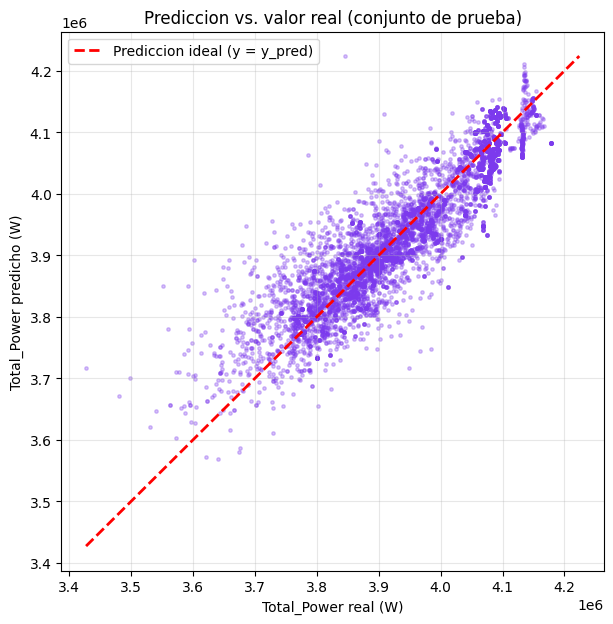

In [20]:
# Grafica Prediccion vs Valor real (conjunto de prueba)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, s=6, alpha=0.3, color='#7c3aed')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Prediccion ideal (y = y_pred)')
plt.xlabel('Total_Power real (W)')
plt.ylabel('Total_Power predicho (W)')
plt.title('Prediccion vs. valor real (conjunto de prueba)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Ecuación de la normal

Como en el cuadernillo original, se calcula también la solución exacta mediante la **ecuación de la normal**:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Al ser la regresión lineal un problema **convexo**, esta solución representa el **mínimo global** de $J(\theta)$ para el modelo lineal. Se compara con el resultado del descenso por el gradiente para verificar que este último alcanzó (o se aproximó lo suficiente a) el menor costo posible.


In [21]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

theta_normal = normalEqn(X_train_b, y_train_norm)

J_normal_train = computeCostMulti(X_train_b, y_train_norm, theta_normal)
J_gd_train = computeCostMulti(X_train_b, y_train_norm, theta)

print(f'Costo (train) - Descenso por el gradiente : {J_gd_train:.6f}')
print(f'Costo (train) - Ecuacion de la normal      : {J_normal_train:.6f}  (minimo global teorico)')
print(f'Diferencia relativa                        : {abs(J_gd_train - J_normal_train) / J_normal_train * 100:.4f} %')


Costo (train) - Descenso por el gradiente : 0.083647
Costo (train) - Ecuacion de la normal      : 0.083647  (minimo global teorico)
Diferencia relativa                        : 0.0002 %


El costo obtenido mediante el **descenso por el gradiente** con $\alpha = 0.1$ y 1500 iteraciones es prácticamente idéntico al mínimo global calculado con la **ecuación de la normal**, lo que confirma que el entrenamiento **convergió al menor error de costo posible** para un modelo de regresión lineal sobre este conjunto de características.

## 10. Inferencia con nuevos ejemplos

Finalmente, se usa el modelo entrenado ($\theta$ obtenido por descenso por el gradiente) para **inferir la potencia total** que generaría un arreglo de boyas dado, a partir únicamente de sus coordenadas (X, Y). Se muestran ejemplos tomados del conjunto de prueba (no vistos en el entrenamiento) comparando el valor real contra el predicho.


In [22]:
def predecir_total_power(x_raw, theta, mu_X, sigma_X, mu_y, sigma_y):
    # x_raw: vector de 98 posiciones [X1,Y1,X2,Y2,...,X49,Y49] en metros (sin normalizar)
    x_norm = (np.array(x_raw, dtype=float) - mu_X) / sigma_X
    x_b = np.concatenate([[1.0], x_norm])
    pred_norm = np.dot(x_b, theta)
    return desnormalizar(pred_norm, mu_y, sigma_y)

# Ejemplo: se toman 5 configuraciones aleatorias del conjunto de prueba
np.random.seed(1)
sample_idx = np.random.choice(m_test, 5, replace=False)

print(f'{"Real (W)":>15} {"Predicho (W)":>15} {"Error abs (W)":>15}')
for i in sample_idx:
    x_raw = X_test[i]
    real = y_test[i]
    pred = predecir_total_power(x_raw, theta, mu_X, sigma_X, mu_y, sigma_y)
    print(f'{real:15,.1f} {pred:15,.1f} {abs(real - pred):15,.1f}')


       Real (W)    Predicho (W)   Error abs (W)
    3,797,873.5     3,767,716.9        30,156.5
    4,064,935.2     4,066,357.3         1,422.1
    4,130,719.7     4,102,710.4        28,009.3
    3,870,195.8     3,870,637.4           441.6
    3,802,315.1     3,801,266.9         1,048.2


## 11. Conclusiones

- Se adaptó el cuadernillo de regresión lineal múltiple revisado en clases para trabajar con el dataset **WEC_Perth_49** (m = 36 043 ejemplos, n = 98 características ≥ los requisitos de m ≥ 20 000 y n ≥ 20).
- La apertura y el preprocesamiento del dataset se realizaron íntegramente con **Pandas** (`read_csv`, selección de columnas, verificación de nulos, `describe`, `info`).
- Se normalizaron tanto las características de entrada como la variable objetivo, lo que fue clave para lograr una convergencia estable del descenso por el gradiente en un dataset de esta escala.
- Se graficó la función de costo $J(\theta)$ respecto al número de iteración, tanto para la comparación de distintos valores de $\alpha$ como para la convergencia final del modelo entrenado.
- El costo final obtenido mediante descenso por el gradiente es prácticamente igual al mínimo global calculado con la ecuación de la normal, confirmando que se alcanzó **el menor error de costo posible** para un modelo lineal sobre estas características.
- El modelo resultante es capaz de **inferir la potencia total de un arreglo de 49 boyas de energía undimotriz a partir únicamente de su disposición geométrica**, lo cual tiene aplicación directa en la optimización de layouts de granjas de energía renovable.
